In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("creditcard.csv")

In [4]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [9]:
df.median()

Time      84692.000000
V1            0.018109
V2            0.065486
V3            0.179846
V4           -0.019847
V5           -0.054336
V6           -0.274187
V7            0.040103
V8            0.022358
V9           -0.051429
V10          -0.092917
V11          -0.032757
V12           0.140033
V13          -0.013568
V14           0.050601
V15           0.048072
V16           0.066413
V17          -0.065676
V18          -0.003636
V19           0.003735
V20          -0.062481
V21          -0.029450
V22           0.006782
V23          -0.011193
V24           0.040976
V25           0.016594
V26          -0.052139
V27           0.001342
V28           0.011244
Amount       22.000000
Class         0.000000
dtype: float64

In [10]:
df.mode()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,163152.0,1.245674,-0.326668,-2.752041,-0.842316,-0.562777,-1.011073,-0.432126,-0.160211,0.170362,...,-0.262581,-0.816264,0.020675,0.357827,0.186423,-0.398828,-0.035866,-0.060282,1.0,0.0
1,NaN,2.055797,0.166975,0.488306,0.635322,2.463072,3.173856,0.014953,0.727706,0.608606,...,0.269765,0.844627,0.140304,0.726212,0.366624,0.096544,0.027735,0.018495,NaN,NaN


# EDA

In [11]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(1081)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [16]:
df["Class"].value_counts(normalize = True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

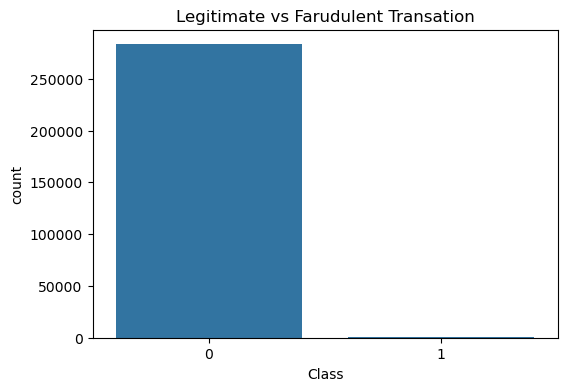

In [17]:
# visualize class imbalance
plt.figure(figsize = (6,4))
sns.countplot(x = "Class", data = df)
plt.title("Legitimate vs Farudulent Transation")
plt.xlabel("Class")
plt.ylabel("count")
plt.show()

In [18]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


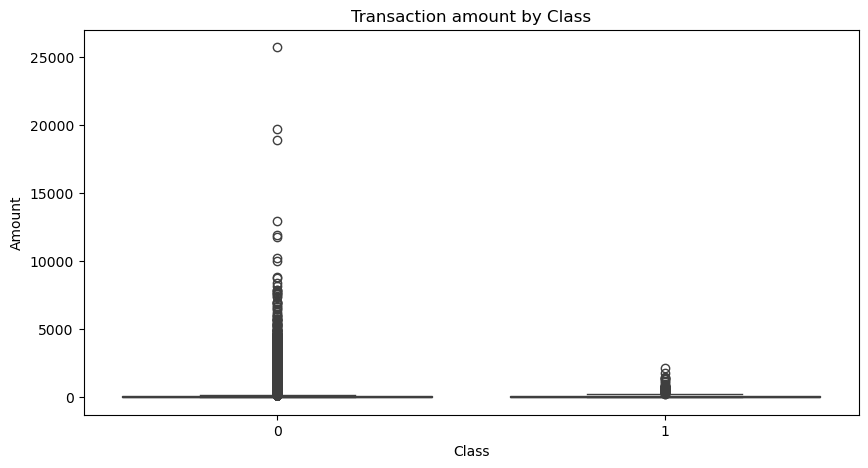

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x = "Class", y = "Amount" ,data=df)
plt.title("Transaction amount by Class")
plt.show()

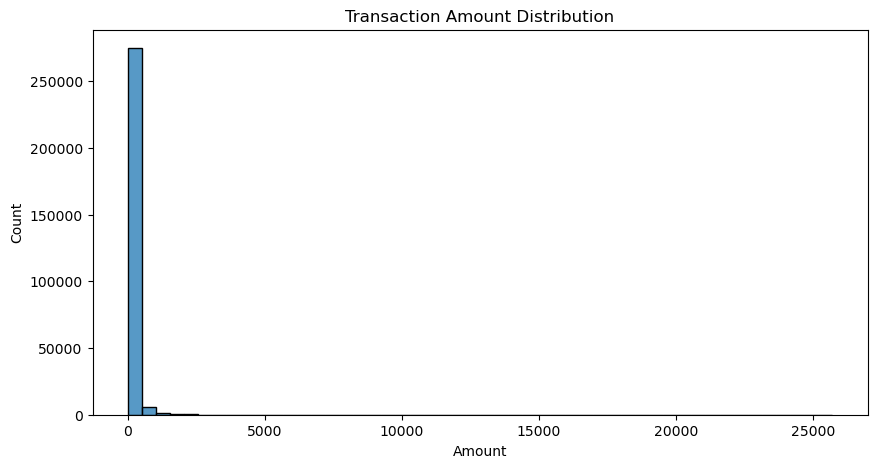

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

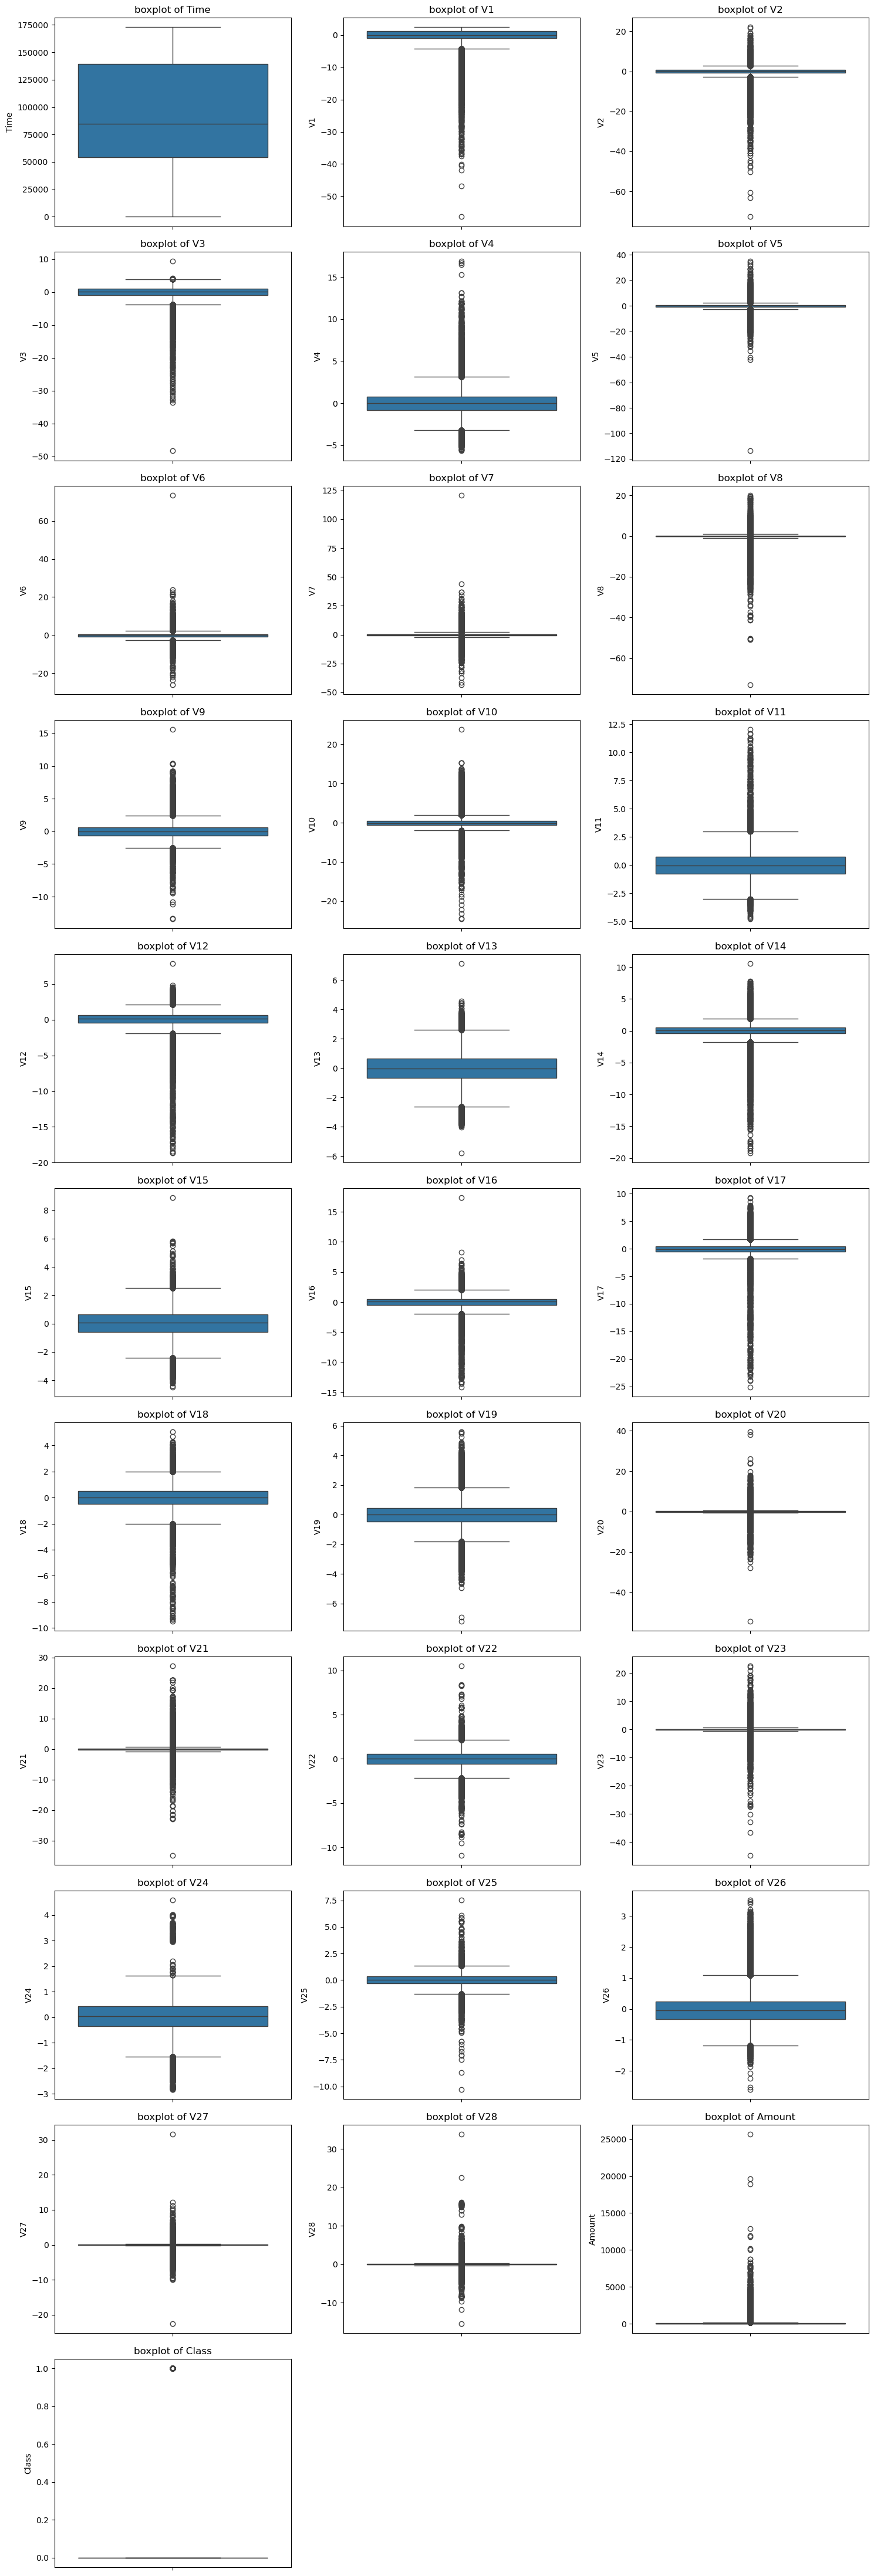

In [21]:
numeric_cols = df.select_dtypes(include = ["float64","int64"]).columns
n = len(numeric_cols)
rows = (n + 2)//3
plt.figure(figsize = (15,rows*4))

for i,col in enumerate(numeric_cols,1):
    plt.subplot(rows, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"boxplot of {col}")
plt.tight_layout()
plt.show()

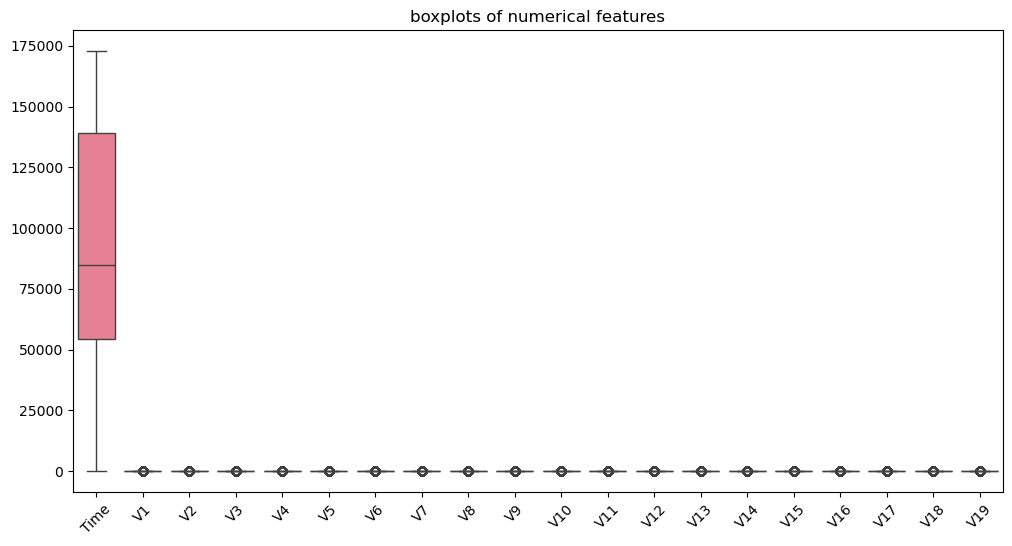

In [22]:
plt.figure(figsize = (12,6))
sns.boxplot(data=df[numeric_cols[:20]])
plt.xticks(rotation = 45)
plt.title("boxplots of numerical features")
plt.show()

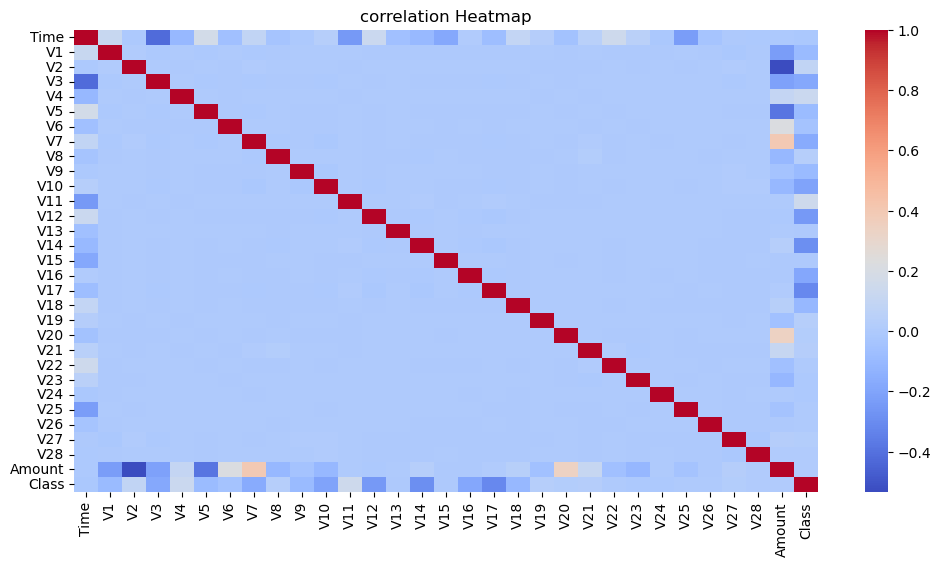

In [23]:
plt.figure(figsize=(12,6))
corr = df.corr(numeric_only = True)
sns.heatmap(
    corr, 
    cmap = "coolwarm", 
    annot = False)
plt.title("correlation Heatmap")
plt.show()

In [24]:
top_corr = corr["Class"].sort_values(ascending = False)
print(top_corr.head(10))

Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64


  # Preprocesing

In [25]:
# separate Feature and target
x = df.drop("Class",axis = 1)
y = df["Class"]
print("shape of x", x.shape)
print("shape of y", y.shape)

shape of x (283726, 30)
shape of y (283726,)


In [26]:
# Trin test split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state =42, stratify = y)

In [27]:
x_train

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,144549.0,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,32.00
134253,80716.0,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,6.99
186465,127116.0,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,14.95
149493,91342.0,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,17.30
18461,29522.0,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,24.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225116,144113.0,-0.098309,-0.382823,0.202726,-0.732301,0.336342,-0.253872,0.837947,-0.402611,-1.424484,...,0.028820,0.154790,1.009327,0.002124,-0.462865,-0.422526,0.010597,0.041090,-0.004501,124.00
3525,3013.0,-1.708940,-1.296255,1.953170,-2.277028,-0.510388,0.408807,0.329231,0.477331,1.058119,...,0.557379,0.466843,0.860939,0.361317,-0.264732,0.423478,0.065689,-0.026392,0.077562,261.80
242674,151594.0,-0.875424,1.159992,0.573970,1.178888,-0.206267,0.260623,0.371124,0.443532,-0.011588,...,-0.353885,-0.100597,-0.157726,0.049751,-0.014156,-0.513855,-0.771982,-0.242970,0.094879,37.00
60594,49395.0,1.247036,0.348595,0.589407,0.982998,-0.222000,-0.452687,-0.012336,-0.140168,0.052173,...,-0.042753,-0.211495,-0.556038,0.037106,-0.133330,0.403622,-0.595756,0.043911,0.032002,5.00


In [28]:
y_train

226238    0
134253    0
186465    0
149493    0
18461     0
         ..
225116    0
3525      0
242674    0
60594     0
67057     0
Name: Class, Length: 226980, dtype: int64

In [29]:
print("testing shape:", x_train.shape)
print("testing shape:", x_test.shape)

testing shape: (226980, 30)
testing shape: (56746, 30)


In [30]:
# Feature Scaling
# from sklearn.preprocessing import Standardscaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [31]:
x_train_scaled

array([[ 1.04549909,  1.14719836, -1.04203246, ...,  0.09278213,
        -0.15619266, -0.22943372],
       [-0.29869002, -0.67791131,  0.99194846, ..., -0.04986389,
         0.15383143, -0.33119698],
       [ 0.67839667,  0.97765362,  0.0162054 , ...,  0.11132947,
        -0.16581986, -0.29880852],
       ...,
       [ 1.19385202, -0.45214212,  0.70655379, ..., -0.62638332,
         0.28835592, -0.20908921],
       [-0.95824459,  0.63781446,  0.21468286, ...,  0.10812079,
         0.09533138, -0.3392941 ],
       [-0.89610272,  0.52361687, -0.13216317, ...,  0.1416972 ,
        -0.0070969 , -0.30955042]], shape=(226980, 30))

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), ["Time", "Amount"])
    ],
    remainder="passthrough"
)

In [33]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [34]:
x_train_processed

array([[ 1.04549909e+00, -2.29433724e-01,  2.23895390e+00, ...,
        -1.59167327e-01,  3.79201394e-02, -4.99319491e-02],
       [-2.98690019e-01, -3.31196981e-01, -1.31506181e+00, ...,
        -2.66503225e-01, -1.77942077e-02,  5.10578519e-02],
       [ 6.78396673e-01, -2.98808515e-01,  1.90880131e+00, ...,
         7.75758437e-03,  4.51643157e-02, -5.30679919e-02],
       ...,
       [ 1.19385202e+00, -2.09089210e-01, -8.75423998e-01, ...,
        -7.71981893e-01, -2.42969808e-01,  9.48789693e-02],
       [-9.58244594e-01, -3.39294097e-01,  1.24703631e+00, ...,
        -5.95755893e-01,  4.39110766e-02,  3.20015657e-02],
       [-8.96102723e-01, -3.09550419e-01,  1.02466061e+00, ...,
         5.38488859e-01,  5.70252739e-02, -1.36426626e-03]],
      shape=(226980, 30))

In [35]:
# class imbalance
class_weight = "balanced"
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

In [36]:
# SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train_scaled,
    y_train
)

In [37]:
y_train_smote.value_counts()

Class
0    226602
1    226602
Name: count, dtype: int64

In [38]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [39]:
pipeline.fit(x_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,penalty,'l2'


# model building

 Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(
    class_weight = "balanced",
    max_iter = 1000,
    random_state = 42
)
model_lr.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
y_pred = model_lr.predict(x_test_scaled)

In [42]:
y_prob = model_lr.predict_proba(x_test_scaled)[:,1]

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[55262  1389]
 [   12    83]]


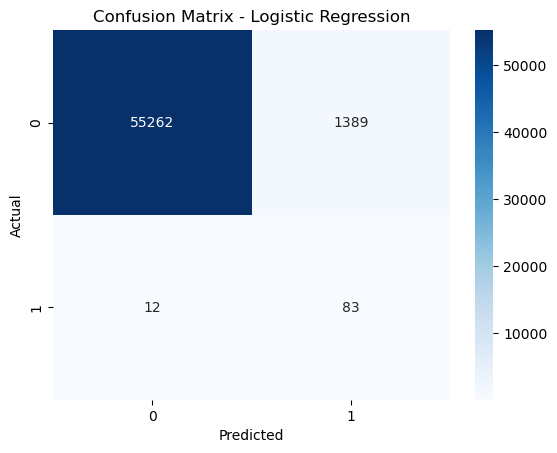

In [44]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [45]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



In [46]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.05638586956521739


In [47]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.8736842105263158


In [48]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("F1:", f1)

F1: 0.10593490746649649


In [49]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9656548079701293


In [50]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

PR-AUC: 0.6719244530518994


In [51]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9753110351390406


In [52]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

Confusion Matrix:
[[55262  1389]
 [   12    83]]
Precision: 0.05638586956521739
Recall: 0.8736842105263158
F1 Score: 0.10593490746649649
ROC-AUC: 0.9656548079701293
PR-AUC: 0.6719244530518994


Random Rorest

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
model_rf = RandomForestClassifier(
    n_estimators = 50,
    class_weight = "balanced",
    random_state = 42,
    n_jobs = -1
)
model_rf.fit(x_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
y_pred_rf = model_rf.predict(x_test_scaled)
y_prob_rf = model_rf.predict_proba(x_test_scaled)[:,1]

In [56]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_rf))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       1.00      0.15      0.26        95

    accuracy                           1.00     56746
   macro avg       1.00      0.57      0.63     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56651     0]
 [   81    14]]
Precision: 1.0
Recall: 0.14736842105263157
F1: 0.25688073394495414
ROC-AUC: 0.9006167030079832
PR-AUC: 0.7681632592202273


In [57]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.9985725866140345


In [58]:
# compare two model 
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, y_prob_rf)
    ]
})

results

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.056386,0.873684,0.105935,0.965655,0.671924
1,Random Forest,1.000000,0.147368,0.256881,0.900617,0.768163


 feature importance

In [59]:
importance = pd.Series(
    model_rf.feature_importances_,
    index = x.columns
).sort_values(ascending=False)

importance.head(10)

V14    0.269893
V10    0.105876
V17    0.094229
V4     0.090391
V3     0.077301
V12    0.073936
V16    0.061590
V2     0.023330
V9     0.021834
V7     0.019999
dtype: float64

plt.figure(figsize=(10, 6))

importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

# SMOTE and Class Imbalance Experiment

In [60]:
from sklearn.linear_model import LogisticRegression
lr_somte = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)
lr_somte.fit(x_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [61]:
y_pred_smote = lr_somte.predict(x_test_scaled)
y_prob_smote = lr_somte.predict_proba(x_test_scaled)[:,1]

In [62]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

precision_smote = precision_score(
    y_test,
    y_pred_smote
)

recall_smote = recall_score(
    y_test,
    y_pred_smote
)

f1_smote = f1_score(
    y_test,
    y_pred_smote
)

roc_auc_smote = roc_auc_score(
    y_test,
    y_prob_smote
)

pr_auc_smote = average_precision_score(
    y_test,
    y_prob_smote
)

print("Precision:", precision_smote)
print("Recall:", recall_smote)
print("F1:", f1_smote)
print("ROC-AUC:", roc_auc_smote)
print("PR-AUC:", pr_auc_smote)

Precision: 0.053035143769968054
Recall: 0.8736842105263158
F1: 0.1
ROC-AUC: 0.9626184886409772
PR-AUC: 0.6750409387333339


In [63]:
# compare with previous model
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SMOTE + Logistic Regression"
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_smote
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_smote
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_smote
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_smote
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, y_prob_rf),
        pr_auc_smote
    ]
})

results

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.056386,0.873684,0.105935,0.965655,0.671924
1,Random Forest,1.000000,0.147368,0.256881,0.900617,0.768163
2,SMOTE + Logistic Regression,0.053035,0.873684,0.100000,0.962618,0.675041


In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=40,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(x_train_smote, y_train_smote)

,n_estimators,40
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
y_pred_rf_smote = rf_smote.predict(x_test_scaled)
y_prob_rf_smote = rf_smote.predict_proba(x_test_scaled)[:, 1]

In [66]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

precision_rf_smote = precision_score(
    y_test, y_pred_rf_smote
)

recall_rf_smote = recall_score(
    y_test, y_pred_rf_smote
)

f1_rf_smote = f1_score(
    y_test, y_pred_rf_smote
)

roc_auc_rf_smote = roc_auc_score(
    y_test, y_prob_rf_smote
)

pr_auc_rf_smote = average_precision_score(
    y_test, y_prob_rf_smote
)

print("Precision:", precision_rf_smote)
print("Recall:", recall_rf_smote)
print("F1:", f1_rf_smote)
print("ROC-AUC:", roc_auc_rf_smote)
print("PR-AUC:", pr_auc_rf_smote)

Precision: 0.9102564102564102
Recall: 0.7473684210526316
F1: 0.8208092485549133
ROC-AUC: 0.9471131182707789
PR-AUC: 0.8000895998088604


# all 4 complete comparison

In [67]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression + Class Weight",
        "Random Forest + Class Weight",
        "SMOTE + Logistic Regression",
        "SMOTE + Random Forest"
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_smote,
        precision_rf_smote
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_smote,
        recall_rf_smote
    ],

    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_smote,
        f1_rf_smote
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_smote,
        roc_auc_rf_smote
    ],

    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, y_prob_rf),
        pr_auc_smote,
        pr_auc_rf_smote
    ]
})

results.sort_values("PR-AUC", ascending=False)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
3,SMOTE + Random Forest,0.910256,0.747368,0.820809,0.947113,0.800090
1,Random Forest + Class Weight,1.000000,0.147368,0.256881,0.900617,0.768163
2,SMOTE + Logistic Regression,0.053035,0.873684,0.100000,0.962618,0.675041
0,Logistic Regression + Class Weight,0.056386,0.873684,0.105935,0.965655,0.671924


In [68]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [69]:
from xgboost import XGBClassifier

In [70]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("scale_pos_weight:",scale_pos_weight)

scale_pos_weight: 599.4761904761905


In [71]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    x_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [72]:
y_pred_xgb = xgb_model.predict(x_test)
y_prob_xgb = xgb_model.predict_proba(x_test)[:,1]

In [73]:
print("Precision:",
      precision_score(y_test, y_pred_xgb))

print("Recall:",
      recall_score(y_test, y_pred_xgb))

print("F1:",
      f1_score(y_test, y_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_xgb))
print("confusion_matrix:",
      confusion_matrix(y_test,y_pred_xgb))

Precision: 0.8735632183908046
Recall: 0.8
F1: 0.8351648351648352
ROC-AUC: 0.9768911962347485
PR-AUC: 0.8130232794358793
confusion_matrix: [[56640    11]
 [   19    76]]


# compare all 5 models

In [74]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

models = {
    "Logistic Regression + Class Weight": (y_pred, y_prob),
    "Random Forest + Class Weight": (y_pred_rf, y_prob_rf),
    "SMOTE + Logistic Regression": (y_pred_smote, y_prob_smote),
    "SMOTE + Random Forest": (y_pred_rf_smote, y_prob_rf_smote),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}

comparison = []

for name, (pred, prob) in models.items():

    comparison.append({
        "Model": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

comparison_df = pd.DataFrame(comparison)

comparison_df.sort_values(
    by="PR-AUC",
    ascending=False
)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
4,XGBoost,0.873563,0.800000,0.835165,0.976891,0.813023
3,SMOTE + Random Forest,0.910256,0.747368,0.820809,0.947113,0.800090
1,Random Forest + Class Weight,1.000000,0.147368,0.256881,0.900617,0.768163
2,SMOTE + Logistic Regression,0.053035,0.873684,0.100000,0.962618,0.675041
0,Logistic Regression + Class Weight,0.056386,0.873684,0.105935,0.965655,0.671924


 # Threshould Tuning

In [75]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.509677,0.831579,0.632000
1,0.15,0.601562,0.810526,0.690583
2,0.20,0.669565,0.810526,0.733333
3,0.25,0.719626,0.810526,0.762376
4,0.30,0.754902,0.810526,0.781726
5,0.35,0.777778,0.810526,0.793814
6,0.40,0.819149,0.810526,0.814815
7,0.45,0.873563,0.800000,0.835165
8,0.50,0.873563,0.800000,0.835165
9,0.55,0.883721,0.800000,0.839779


In [76]:
# threshold with the highest F1
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold

Threshold    0.800000
Precision    0.948718
Recall       0.778947
F1           0.855491
Name: 14, dtype: float64

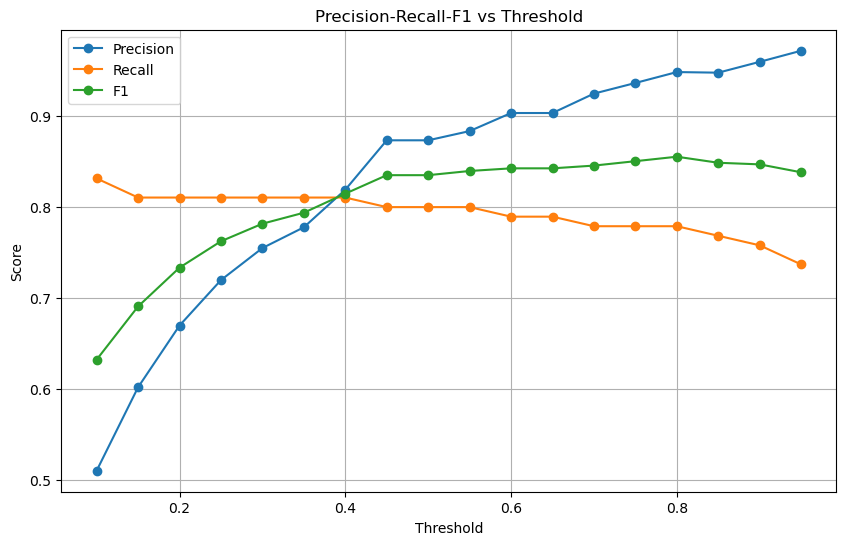

In [77]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 vs Threshold")
plt.legend()
plt.grid()
plt.show()

In [78]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = 0.35

final_prediction = (
        y_prob_xgb >= threshold
    ).astype(int)
final_result = [{
"Precision": precision_score(
    y_test,
    final_prediction,
    zero_division=0
),
"Recall": recall_score(
    y_test,
    final_prediction,
    zero_division=0
),
"F1": f1_score(
    y_test,
    final_prediction,
    zero_division=0    
)
}]

threshold_df = pd.DataFrame(final_prediction)

threshold_df

,0
0,0
1,0
2,0
3,0
4,0
...,...
56741,0
56742,0
56743,0
56744,0


In [79]:
threshold = 0.35

final_predictions = (y_prob_xgb >= threshold).astype(int)

print("Threshold:", threshold)
print("Precision:", precision_score(y_test, final_predictions, zero_division=0))
print("Recall:", recall_score(y_test, final_predictions, zero_division=0))
print("F1 Score:", f1_score(y_test, final_predictions, zero_division=0))

Threshold: 0.35
Precision: 0.7777777777777778
Recall: 0.8105263157894737
F1 Score: 0.7938144329896907


In [80]:
print(pd.Series(final_predictions).value_counts())

0    56647
1       99
Name: count, dtype: int64


# cross validation and Hyperparameter Tuning

In [81]:
# create the xgboost calssifier pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("smote",
SMOTE(random_state = 42)),
    ("model",XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [82]:
xgb_pipeline.fit(x_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


In [83]:
y_pred_xgb_smote = xgb_pipeline.predict(x_test)
y_prob_xgb_smote = xgb_pipeline.predict_proba(x_test)[:,1]

In [84]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_smote))

print("confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb_smote))


print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_smote))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb_smote))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.80      0.81        95

    accuracy                           1.00     56746
   macro avg       0.91      0.90      0.91     56746
weighted avg       1.00      1.00      1.00     56746

confusion matrix:
[[56635    16]
 [   19    76]]
ROC-AUC: 0.9573445537729162
PR-AUC: 0.8142832578721059


In [85]:
cm_xgb = confusion_matrix(y_test,y_pred_xgb_smote)
print(cm_xgb)

[[56635    16]
 [   19    76]]


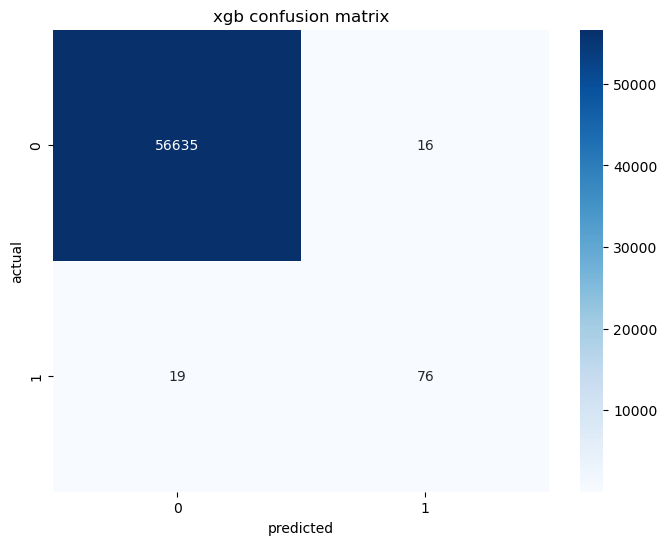

In [86]:
plt.figure(figsize = (8,6))
sns.heatmap(cm_xgb, annot = True, fmt ="d", cmap = "Blues")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("xgb confusion matrix")
plt.show()

In [87]:
# Stratified K fold

In [88]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Create Stratified 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate the complete SMOTE + XGBoost pipeline
cv_results = cross_validate(
    estimator=xgb_pipeline,
    X=x_train,
    y=y_train,
    cv=cv,
    scoring={
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=1
)

# Display results for each fold
print("Precision:", cv_results["test_precision"])
print("Recall:", cv_results["test_recall"])
print("F1 Score:", cv_results["test_f1"])
print("ROC-AUC:", cv_results["test_roc_auc"])

# Display average performance
print("\nAverage Results:")
print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall:", cv_results["test_recall"].mean())
print("Mean F1 Score:", cv_results["test_f1"].mean())
print("Mean ROC-AUC:", cv_results["test_roc_auc"].mean())

Precision: [0.89552239 0.86486486 0.76623377 0.8375     0.79761905]
Recall: [0.8        0.85333333 0.77631579 0.88157895 0.88157895]
F1 Score: [0.84507042 0.8590604  0.77124183 0.85897436 0.8375    ]
ROC-AUC: [0.98272177 0.97335834 0.9762824  0.98803015 0.98564506]

Average Results:
Mean Precision: 0.832348013355476
Mean Recall: 0.838561403508772
Mean F1 Score: 0.8343694028518988
Mean ROC-AUC: 0.9812075442803401


In [89]:
# HYPER PARAMETER

In [90]:
from sklearn.model_selection import RandomizedSearchCV

In [91]:
param_grid = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3]
}
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [92]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 8, 'model__learning_rate': 0.2, 'model__gamma': 0.3, 'model__colsample_bytree': 0.8}


In [93]:
best_xgb = random_search.best_estimator_

In [94]:
y_prob_best = best_xgb.predict_proba(x_test)[:, 1]

y_pred_best = (y_prob_best >= 0.5).astype(int)

In [95]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("classification_report:")
print(classification_report(
    y_test,
    y_pred_best
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_best
))

print("Precision:",
      precision_score(y_test, y_pred_best))

print("Recall:",
      recall_score(y_test, y_pred_best))

print("F1:",
      f1_score(y_test, y_pred_best))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_best))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_best))

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.86      0.79      0.82        95

    accuracy                           1.00     56746
   macro avg       0.93      0.89      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56639    12]
 [   20    75]]
Precision: 0.8620689655172413
Recall: 0.7894736842105263
F1: 0.8241758241758241
ROC-AUC: 0.9691889119809285
PR-AUC: 0.8118917533808844


# compared untuned vs tuned xgboost

In [97]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

comparison = pd.DataFrame({
    "Model": ["xgb_pipeline", "randomsearchcv"],
    
    "Precision": [
        precision_score(y_test, y_pred_xgb_smote),
        precision_score(y_test, y_pred_best)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_xgb_smote),
        recall_score(y_test, y_pred_best)
    ],
    
    "F1": [
        f1_score(y_test, y_pred_xgb_smote),
        f1_score(y_test, y_pred_best)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_xgb_smote),
        roc_auc_score(y_test, y_prob_best)
    ],
    
    "PR-AUC": [
        average_precision_score(y_test, y_prob_xgb_smote),
        average_precision_score(y_test, y_prob_best)
    ]
})

comparison

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,xgb_pipeline,0.826087,0.800000,0.812834,0.957345,0.814283
1,randomsearchcv,0.862069,0.789474,0.824176,0.969189,0.811892


In [98]:
best_xgb
y_prob_final = best_xgb.predict_proba(x_test)[:, 1]

In [99]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.05, 0.96, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_prob_final >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.05,0.500000,0.810526,0.618474
1,0.06,0.534722,0.810526,0.644351
2,0.07,0.553957,0.810526,0.658120
3,0.08,0.578947,0.810526,0.675439
4,0.09,0.596899,0.810526,0.687500


In [100]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_row)

Threshold    0.850000
Precision    0.925000
Recall       0.778947
F1           0.845714
Name: 80, dtype: float64


# Final Threshold

In [102]:
final_threshold = 0.85
y_prob_final = best_xgb.predict_proba(x_test)[:,1]
y_pred_final = (
    y_prob_final >= final_threshold
).astype(int)

In [103]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred_final))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1:", f1_score(y_test, y_pred_final))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_final))
print("PR-AUC:", average_precision_score(y_test, y_prob_final))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.78      0.85        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56645     6]
 [   21    74]]
Precision: 0.925
Recall: 0.7789473684210526
F1: 0.8457142857142858
ROC-AUC: 0.9691889119809285
PR-AUC: 0.8118917533808844


In [106]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 56645
False Positives: 6
False Negatives: 21
True Positives  : 74


In [107]:
recall = recall_score(
    y_test,
    y_pred_final
)

print("Fraud Detection Rate:", recall)

Fraud Detection Rate: 0.7789473684210526


In [108]:
# Precision-Recall Curve

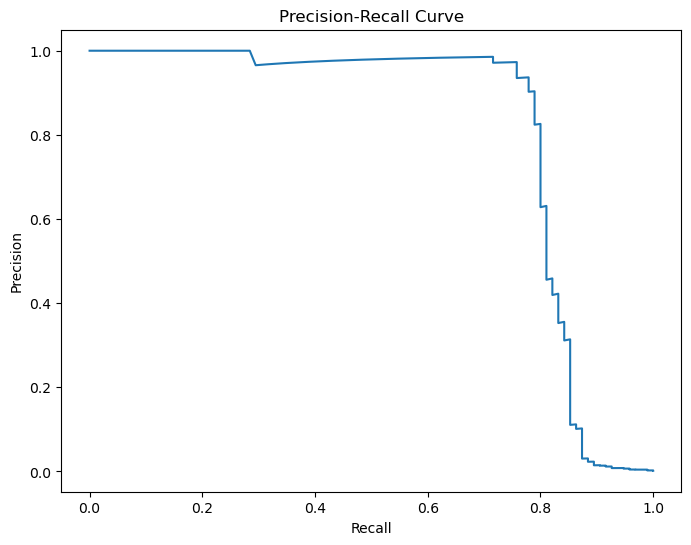

In [110]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_final
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [111]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [112]:
import shap

xgb_model = best_xgb.named_steps["model"]

explainer = shap.TreeExplainer(xgb_model)

In [118]:
x_train_smote, y_train_smote = SMOTE(
    random_state=42
).fit_resample(x_train, y_train)

shap_values = explainer.shap_values(x_train_smote)

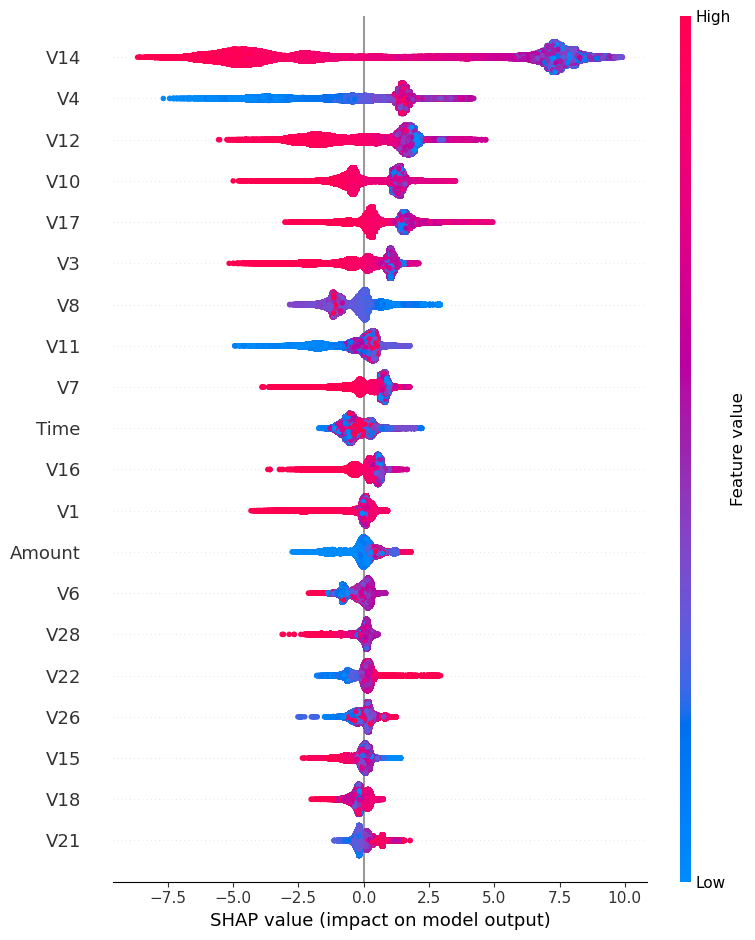

In [119]:
shap.summary_plot(
    shap_values,
    x_train_smote
)

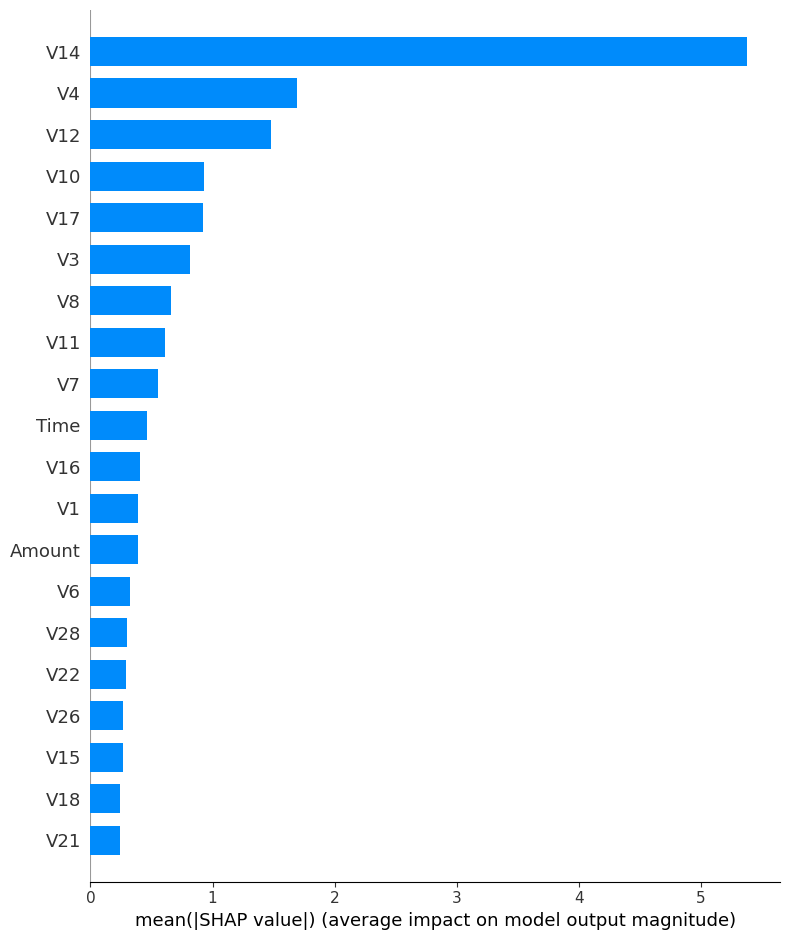

In [120]:
shap.summary_plot(
    shap_values,
    X_train_smote,
    plot_type="bar"
)